# ДЗ №2. Отбор кандидатов


Общая информация
Дата выдачи: 3 февраля 2026

Дедлайн: 23 февраля 2026 23:59 MSK


В этом и последующих домашних заданиях мы построим приближенную к реальной рекомендательную систему. Работать будем с данными marketplace из [T-ECD](https://huggingface.co/datasets/t-tech/T-ECD).

Обычно рекомендательная система состоит из нескольких этапов:
1. Отбор кандидатов (Retrieval)
2. Ранжирование (Ranking)
3. Бизнес-логика (например, условие на то, чтобы товары от одного продавца не стояли в ленте друг за другом)

В этом домашнем задании сосредоточимся на первом этапе.

По ресурсам: at worst нужно 15GB RAM и 3.5GB свободного дискового пространства, GPU не требуется (но можно, если хочется). Дз спокойно запускается на ресурсах Kaggle-а.

In [2]:
!pip install -q polars huggingface_hub implicit faiss-cpu torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.3 MB/s eta 0:00:00:00:0100:01


In [110]:
import glob
import os
import random
import time
import gc
from abc import ABC, abstractmethod
from collections import defaultdict, deque
from math import log2

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from implicit.als import AlternatingLeastSquares
from implicit.ann.faiss import FaissModel
from IPython.display import HTML
from scipy.sparse import coo_matrix, csr_matrix
from torch.utils.data import DataLoader, Dataset, IterableDataset
from tqdm.notebook import tqdm

## Download Data

Данные занимают около 3.5 GB

In [111]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="t-tech/T-ECD",
    repo_type="dataset",
    local_dir=".",
    local_dir_use_symlinks=False,
    allow_patterns=["dataset/small/users.pq", "dataset/small/marketplace/**"]
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

'/kaggle/working'

## EDA (1p)

Изучите данные (users, items, events). Для работы используйте polars - это более оптимизированный аналог pandas. Обратите внимание, что в polars существуют eager и lazy методы работы с таблицами, и зачастую эффективнее использовать lazy.

1. Оцените количество строк и столбцов в таблицах
2. Для всех категориальных переменных рассчитайте частотность каждого признака и процент null-ов. Удобно вывести результат в виде таблицы с помощью следующего кода: `HTML(polars_df.to_pandas().to_html())` - так не нужно будет задумываться про `display.max_rows`
3. Постройте гистограмму для числовых переменных, также оцените процент null-ов
4. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество уникальных пользователей и айтемов за этот день
5. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество событий в разбивке по `action_type`
6. Кликаутят (переходят на сайт партнера) ли люди один и тот же товар несколько раз?
7. Опционально любая другая аналитика на ваше усмотрение (например, можно покластеризовать эмбеддинги товаров и сравнить пересечения кластеров с категориями)

In [5]:
# uppercase для global переменных, чтобы легче видеть их в коде
USERS = pl.read_parquet("dataset/small/users.pq")
ITEMS = pl.read_parquet("dataset/small/marketplace/items.pq")
CATALOG_SIZE = len(ITEMS)

In [6]:
def analyze_categorical(df, df_name):
    """Анализ категориальных переменных"""
    results = []
    
    for col in df.columns:
        dtype = df[col].dtype
        dtype_str = str(dtype)
           
        if "array" in dtype_str.lower():
            continue
            
        if col in ['user_id', 'item_id']:
            continue
            
        if dtype in [pl.Int64, pl.Float64, pl.Int32, pl.Float32]:
            try:
                n_unique = df.select(pl.col(col).n_unique()).item()
                if n_unique > 1000 and n_unique / df.height > 0.1:
                    continue
            except:
                continue
        
        try:
            total = df.height
            
            # Процент null
            null_count = df.filter(pl.col(col).is_null()).height
            null_pct = null_count / total * 100
            
            # Уникальные значения
            try:
                n_unique = df.select(pl.col(col).n_unique()).item()
            except:
                n_unique = "N/A"
            
            # Частотность значений (топ-5)
            try:
                freq = df.group_by(col).agg(pl.len().alias('count')).sort('count', descending=True).head(5)
                if freq.height > 0:
                    top_vals = freq.to_dict(as_series=False)
                    if col in ['category', 'subcategory']:
                        top_vals[col] = [str(v)[:30] + "..." if v and len(str(v)) > 30 else v for v in top_vals[col]]
                    top_values = str(top_vals)
                else:
                    top_values = "N/A"
            except Exception as e:
                top_values = f"Ошибка: {e}"
            
            results.append({
                'table': df_name,
                'column': col,
                'dtype': dtype_str,
                'null_pct': round(null_pct, 2),
                'n_unique': n_unique,
                'top_values': top_values
            })
            
        except Exception as e:
            print(f"Ошибка при анализе колонки {col}: {e}")
            continue
    
    return pl.DataFrame(results)

In [8]:
def plot_numerical_distributions(df, df_name):
    """Гистограммы для числовых переменных"""
    numeric_cols = []
    
    for col in df.columns:
        dtype = df[col].dtype
        if dtype in [pl.Int64, pl.Float64, pl.Int32, pl.Float32] and col not in ['emb']:
            numeric_cols.append(col)
    
    n_cols = len(numeric_cols)
    if n_cols == 0:
        print(f"Нет числовых колонок для {df_name}")
        return
    
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 4))
    if n_cols == 1:
        axes = [axes]
    
    for idx, col in enumerate(numeric_cols):
        data = df.select(col).drop_nulls().to_series()
        if len(data) > 0:
            axes[idx].hist(data, bins=min(50, len(data)), alpha=0.7)
            axes[idx].set_title(f'{df_name} - {col}')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
            
            null_pct = df.filter(pl.col(col).is_null()).height / df.height * 100
            axes[idx].text(0.95, 0.95, f'null: {null_pct:.1f}%', 
                          transform=axes[idx].transAxes, ha='right', 
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

### Users

In [9]:
print(f" Размер таблицы Users: {USERS.shape} - {USERS.height} строк, {USERS.width} столбцов")

print("\n Анализ категориальных признаков USERS ")
users_cat_stats = analyze_categorical(USERS, 'users')
display(HTML(users_cat_stats.to_pandas().to_html()))


print("\nЧисловой анализ USERS")
plot_numerical_distributions(USERS, 'Users')

 Размер таблицы Users: (3500000, 3) - 3500000 строк, 3 столбцов

 Анализ категориальных признаков USERS 


,table,column,dtype,null_pct,n_unique,top_values
0,users,socdem_cluster,UInt8,0.15,22,"{'socdem_cluster': [17, 20, 12, 9, 21], 'count': [473629, 420944, 416287, 340144, 331140]}"
1,users,region,UInt8,1.68,91,"{'region': [2, 60, 90, 18, 24], 'count': [551358, 249920, 181623, 137250, 114992]}"



Числовой анализ USERS
Нет числовых колонок для Users


### Items

 Размер таблицы Items: (2325409, 6) - 2325409 строк, 6 столбцов

 Типы данных в ITEMS
Schema({'item_id': String, 'brand_id': UInt64, 'category': String, 'subcategory': String, 'price': Float64, 'embedding': Array(Float32, shape=(300,))})

Анализ категориальных признаков ITEMS


,table,column,dtype,null_pct,n_unique,top_values
0,items,brand_id,UInt64,0.00,231,"{'brand_id': [47917, 227580, 211031, 52917, 137356], 'count': [227283, 207473, 160267, 116150, 113678]}"
1,items,category,String,41.56,23,"{'category': [None, 'Miscellaneous Goods (Uncategor...', 'Cosmetics, Personal Care, and ...', 'Fashion Accessories, Tech Add-...', 'Outerwear, Casual Apparel, and...'], 'count': [966395, 266146, 188412, 167811, 153223]}"
2,items,subcategory,String,53.02,193,"{'subcategory': [None, 'Jewelry and Costume Jewelry', ""Women's Clothing"", ""Women's Footwear"", ""Men's Clothing""], 'count': [1233023, 99751, 82778, 62212, 46759]}"


Числовой анализ items


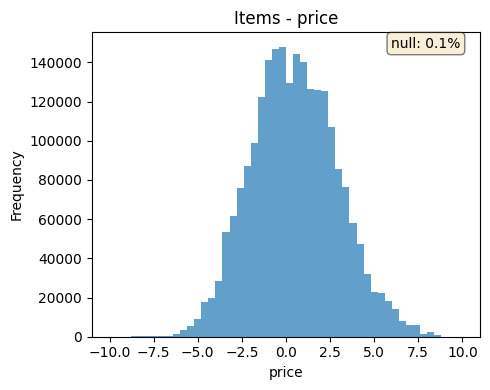

In [10]:
print(f" Размер таблицы Items: {ITEMS.shape} - {ITEMS.height} строк, {ITEMS.width} столбцов")
print("\n Типы данных в ITEMS")
print(ITEMS.schema)
 
print("\nАнализ категориальных признаков ITEMS")
items_cat_stats = analyze_categorical(ITEMS, 'items')
display(HTML(items_cat_stats.to_pandas().to_html()))

print("Числовой анализ items")
plot_numerical_distributions(ITEMS, 'Items')

### Events

shape: (1, 4)
┌───────────────┬────────────────────────────┬───────────────────────────┬────────────┐
│ min_timestamp ┆ max_timestamp              ┆ mean_timestamp            ┆ null_count │
│ ---           ┆ ---                        ┆ ---                       ┆ ---        │
│ duration[μs]  ┆ duration[μs]               ┆ duration[μs]              ┆ u32        │
╞═══════════════╪════════════════════════════╪═══════════════════════════╪════════════╡
│ 1082d 89901µs ┆ 1308d 23h 59m 58s 175560µs ┆ 1202d 17h 14m 51s 99035µs ┆ 0          │
└───────────────┴────────────────────────────┴───────────────────────────┴────────────┘

Диапазон timestamp: от 1082 days, 0:00:00.089901 до 1308 days, 23:59:58.175560

 Cтатистика по дням
Всего дней в данных: 227
Диапазон дней: от 0 до 226

Первые 10 дней:
shape: (10, 5)
┌────────────┬──────────────┬──────────────┬──────────────┬─────────────────────────────┐
│ day_number ┆ unique_users ┆ unique_items ┆ total_events ┆ actions_list                │
│ ---

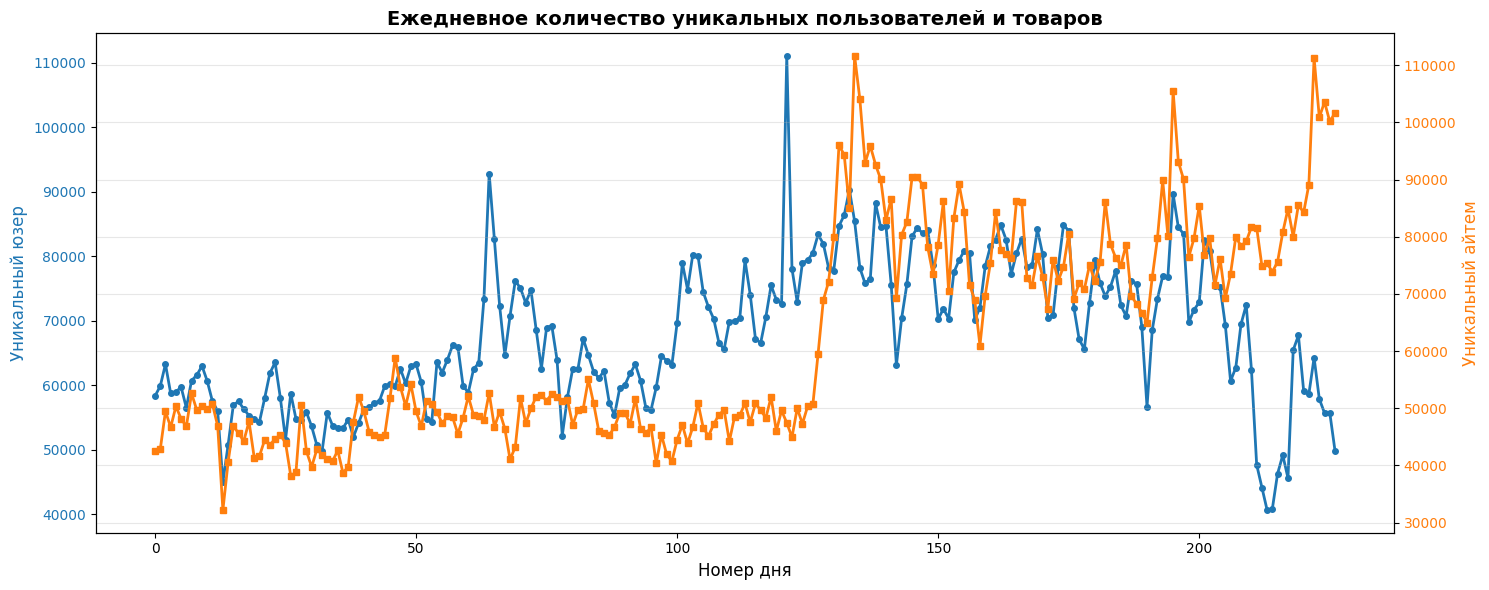


 Статистика по типам действий (первые 5 дней)
shape: (5, 6)
┌─────┬────────┬──────┬───────────┬──────────┬──────────┐
│ day ┆ view   ┆ like ┆ addtocart ┆ purchase ┆ clickout │
│ --- ┆ ---    ┆ ---  ┆ ---       ┆ ---      ┆ ---      │
│ i64 ┆ i64    ┆ i64  ┆ i64       ┆ i64      ┆ i64      │
╞═════╪════════╪══════╪═══════════╪══════════╪══════════╡
│ 0   ┆ 483181 ┆ 181  ┆ 0         ┆ 0        ┆ 2014     │
│ 1   ┆ 494538 ┆ 208  ┆ 0         ┆ 0        ┆ 2136     │
│ 2   ┆ 516270 ┆ 266  ┆ 0         ┆ 0        ┆ 2243     │
│ 3   ┆ 477429 ┆ 126  ┆ 0         ┆ 0        ┆ 2124     │
│ 4   ┆ 500546 ┆ 334  ┆ 0         ┆ 0        ┆ 2547     │
└─────┴────────┴──────┴───────────┴──────────┴──────────┘


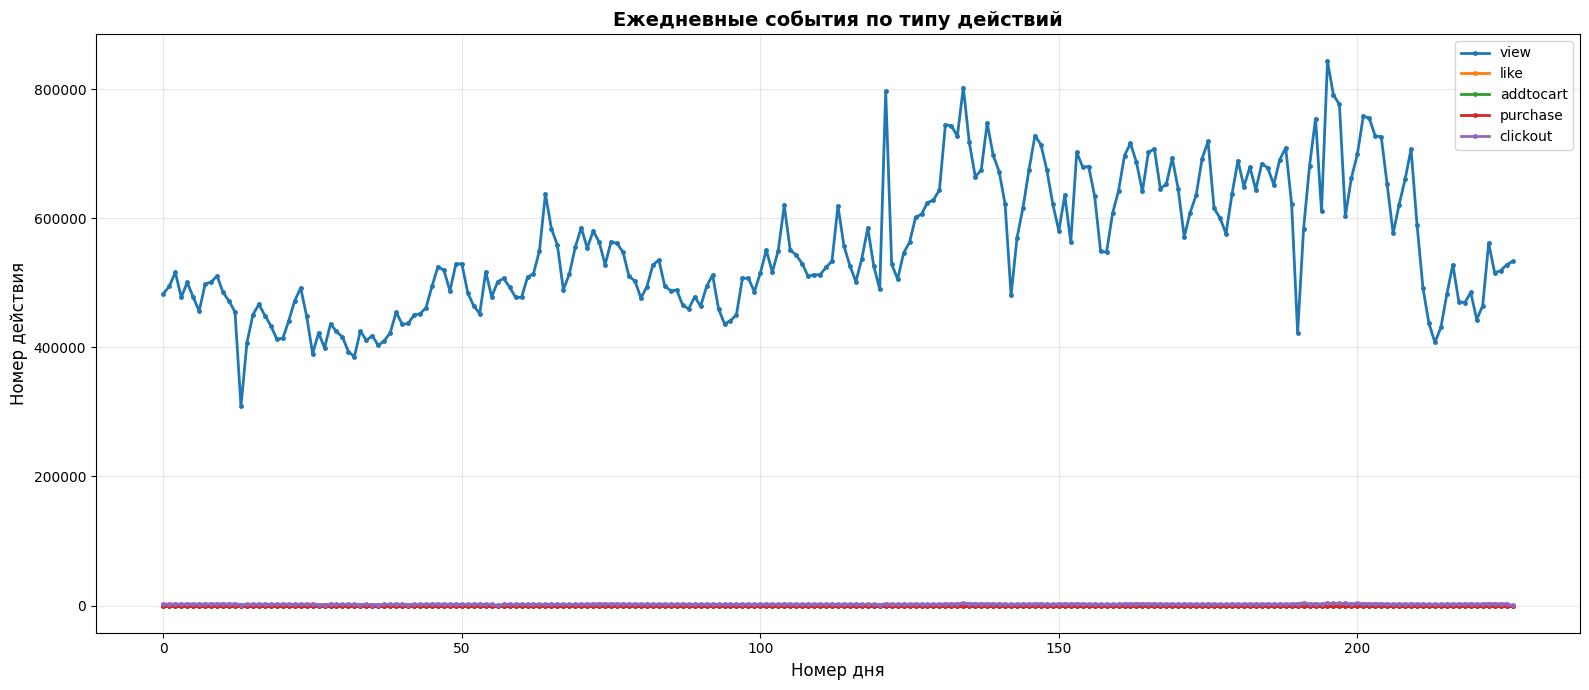

In [11]:
EVENTS = pl.read_parquet("dataset/small/marketplace/events")

timestamp_stats = EVENTS.select([
    pl.col("timestamp").min().alias("min_timestamp"),
    pl.col("timestamp").max().alias("max_timestamp"),
    pl.col("timestamp").mean().alias("mean_timestamp"),
    pl.col("timestamp").is_null().sum().alias("null_count")
])
print(timestamp_stats)

min_ts = timestamp_stats["min_timestamp"][0]
max_ts = timestamp_stats["max_timestamp"][0]

print(f"\nДиапазон timestamp: от {min_ts} до {max_ts}")


# Преобразуем duration в секунды для удобства
EVENTS = EVENTS.with_columns([
    (pl.col("timestamp").cast(pl.Int64) / 1_000_000).cast(pl.Int64).alias("timestamp_sec")
])

EVENTS_LAZY = EVENTS.lazy()

# Находим минимальный timestamp для отсчета
min_ts = EVENTS['timestamp_sec'].min()

# Создаем номер дня 
EVENTS_WITH_DAY = EVENTS_LAZY.with_columns([
    ((pl.col("timestamp_sec") - min_ts) // 86400).alias("day_number"),
    (((pl.col("timestamp_sec") - min_ts) % 86400) // 3600).cast(pl.Int32).alias("hour_calc"),
])

# Группировка по номеру дня
daily_stats = EVENTS_WITH_DAY.group_by("day_number").agg([
    pl.col("user_id").n_unique().alias("unique_users"),
    pl.col("item_id").n_unique().alias("unique_items"),
    pl.len().alias("total_events"),
    pl.col("action_type").alias("actions_list")
]).sort("day_number")

# Собираем результат
daily_stats_df = daily_stats.collect()

print("\n Cтатистика по дням")
print(f"Всего дней в данных: {len(daily_stats_df)}")
print(f"Диапазон дней: от {daily_stats_df['day_number'].min()} до {daily_stats_df['day_number'].max()}")
print("\nПервые 10 дней:")
print(daily_stats_df.head(10))

fig, ax1 = plt.subplots(figsize=(15, 6))

x_days = daily_stats_df['day_number'].to_list()

ax1.set_xlabel('Номер дня', fontsize=12)
ax1.set_ylabel('Уникальный юзер', color='tab:blue', fontsize=12)
ax1.plot(x_days, daily_stats_df['unique_users'].to_list(), 
         color='tab:blue', marker='o', linewidth=2, markersize=4, label='Users')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Уникальный айтем', color='tab:orange', fontsize=12)
ax2.plot(x_days, daily_stats_df['unique_items'].to_list(), 
         color='tab:orange', marker='s', linewidth=2, markersize=4, label='Items')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Ежедневное количество уникальных пользователей и товаров', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


action_types = ['view', 'like', 'addtocart', 'purchase', 'clickout']
daily_actions = []

for row in daily_stats_df.iter_rows():
    day = row[0]
    actions_list = row[4]
    
    action_counts = {action: 0 for action in action_types}
    
    if actions_list is not None:
        for action in actions_list:
            if action in action_counts:
                action_counts[action] += 1
    
    daily_record = {'day': day}
    daily_record.update(action_counts)
    daily_actions.append(daily_record)

daily_actions_df = pl.DataFrame(daily_actions)

print("\n Статистика по типам действий (первые 5 дней)")
print(daily_actions_df.head())

# График по типам действий
plt.figure(figsize=(16, 7))

for action in action_types:
    plt.plot(daily_actions_df['day'].to_list(), 
             daily_actions_df[action].to_list(), 
             marker='.', linewidth=2, markersize=5, label=action)

plt.xlabel('Номер дня', fontsize=12)
plt.ylabel('Номер действия', fontsize=12)
plt.title('Ежедневные события по типу действий', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Анализ повторных кликов

Распределение количества кликов на пару пользователь-товар:
shape: (47, 2)
┌─────────────┬─────────────────┐
│ click_count ┆ user_item_pairs │
│ ---         ┆ ---             │
│ u32         ┆ u32             │
╞═════════════╪═════════════════╡
│ 1           ┆ 391850          │
│ 2           ┆ 24741           │
│ 3           ┆ 6095            │
│ 4           ┆ 2221            │
│ 5           ┆ 980             │
│ …           ┆ …               │
│ 111         ┆ 1               │
│ 112         ┆ 1               │
│ 114         ┆ 1               │
│ 138         ┆ 1               │
│ 163         ┆ 1               │
└─────────────┴─────────────────┘

Всего пар пользователь-товар с кликами: 427192
Пар с повторными кликами (>1): 35342
Процент повторных кликов: 8.27%
Максимальное количество кликов на одну пару: 163


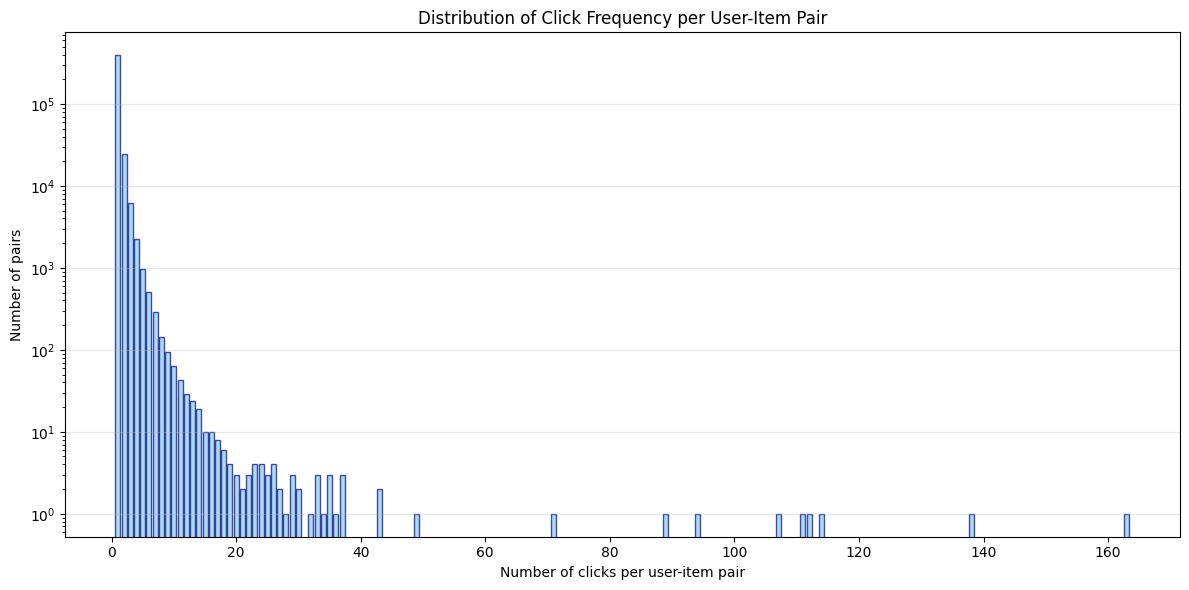

In [12]:
print("Анализ повторных кликов")

if isinstance(EVENTS['action_type'][0], dict):
    clickout_value = 'clickout'
else:
    clickout_value = 'clickout'

clickout_events = EVENTS.filter(
    pl.col("action_type").map_elements(
        lambda x: x.get('action_type', '') if isinstance(x, dict) else str(x)
    ) == clickout_value
) if isinstance(EVENTS['action_type'][0], dict) else EVENTS.filter(pl.col("action_type") == clickout_value)

# Группируем по пользователю и товару
user_item_clicks = clickout_events.group_by(["user_id", "item_id"]).agg([
    pl.len().alias("click_count")
])

# Статистика по количеству кликов
click_stats = user_item_clicks.group_by("click_count").agg([
    pl.len().alias("user_item_pairs")
]).sort("click_count")

print("\nРаспределение количества кликов на пару пользователь-товар:")
print(click_stats)

# Процент повторных кликов
total_pairs = click_stats['user_item_pairs'].sum()
repeat_pairs = click_stats.filter(pl.col('click_count') > 1)['user_item_pairs'].sum()
repeat_percentage = (repeat_pairs / total_pairs * 100) if total_pairs > 0 else 0

print(f"\nВсего пар пользователь-товар с кликами: {total_pairs}")
print(f"Пар с повторными кликами (>1): {repeat_pairs}")
print(f"Процент повторных кликов: {repeat_percentage:.2f}%")

# Максимальное количество кликов
max_clicks = click_stats['click_count'].max()
print(f"Максимальное количество кликов на одну пару: {max_clicks}")

# Гистограмма
plt.figure(figsize=(12, 6))
plt.bar(click_stats['click_count'].to_list(), 
        click_stats['user_item_pairs'].to_list(),
        alpha=0.7, color='skyblue', edgecolor='navy')
plt.xlabel('Number of clicks per user-item pair')
plt.ylabel('Number of pairs')
plt.title('Distribution of Click Frequency per User-Item Pair')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Data Splitting (1p)

Прежде чем обучать какие-либо модели, разобъем данные на train-val-test по временной отметке (темпоральный сплит).

На практике обычно используется следующий подход: сначала модель обучается на train части, на val подбирается лучший набор гиперпараметров. Потом модель обучается на train+val, и финальные метрики замеряются на test.

Допишите функцию так, чтобы:

* в train вошли данные start_day < day <= start_day + n_train_days
* в val вошли данные start_day + n_train_days < day <= start_day + n_train_days + n_val_days
* в test вошли данные start_day + n_train_days + n_val_days < day <= start_day + n_train_days + n_val_days + n_test_days

Где start_day - это номер файла, задающий дату, с которой начинается временной промежуток.

Не будем учитывать повторные взаимодействия в обучающих данных. То есть для каждой пары (пользователь, айтем) в train/train_val необходимо оставить только максимальный лейбл.

Ожидаемую результирующую схему данных можно найти ниже. В val и test нужно оставить только позитивы.

In [14]:
def get_data(
    start_day: int = 1250,
    n_train_days: int = 20,
    n_val_days: int = 3,
    n_test_days: int = 5,
    n_users_to_keep: int = 10_000,
    n_items_to_keep: int = 30_000,
) -> tuple[pl.LazyFrame, pl.LazyFrame, pl.LazyFrame, pl.LazyFrame]:

    events = (
        pl.scan_parquet("dataset/small/marketplace/events/")
        .with_columns(
            label=(
                pl.when(pl.col("action_type") == "view")
                .then(0)
                .otherwise(1)
            )  # `label` равен 1, если `action_type` НЕ равен просмотру, и 0 иначе
        )
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days + n_test_days)
        )
        .sort("timestamp")
        .select("timestamp", "user_id", "item_id", "label")
    )

    # Отфильтруем топ-`n_users_to_keep` пользователей и топ-`n_items_to_keep` айтемов по количеству положительных взаимодействий
    # Это нужно, чтобы не обучать модели на слишком больших матрицах (потому что у нас тут всё-таки дз, а не полноценный продовый сетап)

    user_positive_counts = (
        events
        .group_by("user_id")
        .agg(pl.col("label").sum())
        .sort("label", descending=True)
        .head(n_users_to_keep)
        .select("user_id")
    )

    item_counts = (
        events
        .group_by("item_id")
        .agg(pl.col("label").sum())
        .sort("label", descending=True)
        .head(n_items_to_keep)
        .select("item_id")
    )

    # Кстати, у такого способа фильтрации точно есть проблемы - как минимум то, что что статистика для айтемов считается и по тем юзерам,
    # которые не попали в топ-`n_users_to_keep`. Но в качестве приближения работает вполне неплохо

    events_filtered = (
        events
        .join(user_positive_counts, on="user_id", how="inner")
        .join(item_counts, on="item_id", how="inner")
        .collect()
        .lazy()
    )

    train_end = start_day + n_train_days
    val_end = train_end + n_val_days
    test_end = val_end + n_test_days

    def filter_by_days(df, start, end):
        return df.filter(
            (pl.col("timestamp").dt.total_days() > start) &
            (pl.col("timestamp").dt.total_days() <= end)
        )
    
    train_raw = filter_by_days(events_filtered, start_day, train_end)
    val_raw = filter_by_days(events_filtered, train_end, val_end)
    train_val_raw = filter_by_days(events_filtered, start_day, val_end)
    test_raw = filter_by_days(events_filtered, val_end, test_end)
    
    train_events = (
        train_raw
        .group_by(["user_id", "item_id"])
        .agg([
            pl.col("timestamp").max().alias("timestamp"),
            pl.col("label").max().alias("label")
        ])
        .select(["user_id", "item_id", "timestamp", "label"])
    )

    val_events = train_val_events = (
        train_val_raw
        .group_by(["user_id", "item_id"])
        .agg([
            pl.col("timestamp").max().alias("timestamp"),
            pl.col("label").max().alias("label")
        ])
        .select(["user_id", "item_id", "timestamp", "label"])
    )
    
    val_positives = (
        val_raw
        .filter(pl.col("label") == 1)
        .select(["user_id", "item_id"])
    )
    test_positives = (
        test_raw
        .filter(pl.col("label") == 1)
        .select(["user_id", "item_id"])
    )
    warm_users_val = train_events.select("user_id").unique()
    
    warm_users_test = train_val_events.select("user_id").unique()

    val_events = (
        val_positives
        .join(warm_users_val, on="user_id", how="inner")
        .group_by("user_id")
        .agg(pl.col("item_id").unique().alias("item_id"))
        .select(["user_id", "item_id"])
    )
    
    test_events = (
        test_positives
        .join(warm_users_test, on="user_id", how="inner")
        .group_by("user_id")
        .agg(pl.col("item_id").unique().alias("item_id"))
        .select(["user_id", "item_id"])
    )

    return (
        train_events,
        val_events,
        train_val_events,
        test_events,
        val_raw,
        test_raw,
        warm_users_val,
        warm_users_test,
        val_positives,
        test_positives
    )


(train_events, val_events, train_val_events, test_events, 
 val_raw, test_raw, warm_users_val, warm_users_test, val_positives, test_positives) = get_data()


train_events = train_events.collect()
val_events = val_events.collect()
train_val_events = train_val_events.collect()
test_events = test_events.collect()
val_raw_df = val_raw.collect()
test_raw_df = test_raw.collect()
warm_users_val_df = warm_users_val.collect()
warm_users_test_df = warm_users_test.collect()
val_positives_df = val_positives.collect()
test_positives_df = test_positives.collect()

In [16]:
expected_train_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.String,
    "timestamp": pl.Duration(time_unit='us'),
    "label": pl.Int32
})

expected_val_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.List(pl.String)
})

assert train_events.schema == expected_train_schema
assert val_events.schema == expected_val_schema
assert train_val_events.schema == expected_train_schema
assert test_events.schema == expected_val_schema

Отфильтруйте из валидационного и тестового подмножеств только теплых пользователей (то есть таких, у которых было хотя бы одно взаимодействие в train или train_val части соответственно). Почему так? Модели, которые рассматриваются в данном дз, не умеют работать с холодными пользователями.

Кстати, сколько получается таких холодных пользователей?

In [17]:
# Холодные пользователи в val
cold_users_val = (
    val_positives_df
    .select("user_id")
    .unique()
    .join(
        warm_users_val_df.select("user_id").unique(), 
        on="user_id", 
        how="anti"
    )
)
n_val_users_cold = len(cold_users_val)

n_val_users_total = val_positives_df.select("user_id").unique().height

val_cold_percent = (n_val_users_cold / n_val_users_total * 100) if n_val_users_total > 0 else 0

print(f" Холодных пользователей: {n_val_users_cold}")
print(f" Процент холодных пользователей: {val_cold_percent:.2f}%")

if n_val_users_cold > 0:
    print(f"\nПримеры холодных пользователей (первые 10):")
    print(cold_users_val.head(10))

# Холодные пользователи в test 
cold_users_test = (
    test_positives_df
    .select("user_id")
    .unique()
    .join(
        warm_users_test_df.select("user_id").unique(), 
        on="user_id", 
        how="anti"
    )
)
n_test_users_cold = len(cold_users_test)

n_test_users_total = test_positives_df.select("user_id").unique().height

test_cold_percent = (n_test_users_cold / n_test_users_total * 100) if n_test_users_total > 0 else 0

print(f" Холодных пользователей: {n_test_users_cold}")
print(f" Процент холодных пользователей: {test_cold_percent:.2f}%")

if n_test_users_cold > 0:
    print(f"\nПримеры холодных пользователей (первые 10):")
    print(cold_users_test.head(10))

 Холодных пользователей: 314
 Процент холодных пользователей: 11.69%

Примеры холодных пользователей (первые 10):
shape: (10, 1)
┌──────────┐
│ user_id  │
│ ---      │
│ u64      │
╞══════════╡
│ 72476106 │
│ 42514481 │
│ 15385840 │
│ 86218766 │
│ 62259110 │
│ 46298615 │
│ 51937167 │
│ 54317052 │
│ 26004356 │
│ 13253448 │
└──────────┘
 Холодных пользователей: 387
 Процент холодных пользователей: 9.97%

Примеры холодных пользователей (первые 10):
shape: (10, 1)
┌──────────┐
│ user_id  │
│ ---      │
│ u64      │
╞══════════╡
│ 82007567 │
│ 10668124 │
│ 21528649 │
│ 31908017 │
│ 28730062 │
│ 54988954 │
│ 71832997 │
│ 12385962 │
│ 80016120 │
│ 89677301 │
└──────────┘


In [18]:
print(f"len(train_events) = {len(train_events)}")
print(f"len(val_events) = {len(val_events)}")
print(f"len(train_val_events) = {len(train_val_events)}")
print(f"len(test_events) = {len(test_events)}")

len(train_events) = 693374
len(val_events) = 2371
len(train_val_events) = 782586
len(test_events) = 3496


In [34]:
assert len(train_events) == 693176
assert len(val_events) == 2375
assert len(train_val_events) == 782473
assert len(test_events) == 3488

AssertionError: 

In [19]:
assert round(train_events["label"].mean(), 2) == 0.12
assert round(train_val_events["label"].mean(), 2) == 0.12

In [20]:
val_users = val_events["user_id"].to_list()
test_users = test_events["user_id"].to_list()

## Evaluation (1p)

In [21]:
# сколько рекомендаций будем выдавать для каждого пользователя. можете выбрать другое число
N = 20

### Metrics (0.5p)

Реализуйте набор метрик для оценки качества моделей. Обязательно реализовать HitRate@k (можно взять из прошлой домашки) и Coverage@k. NDCG@k и Recall@k уже реализованы. По желанию можете добавить и другие метрики, например MAP@k, MRR@k и Precision@k.

Условия на векторизацию/обязательность использования polars-а в метриках нет :)

In [22]:
def hit_rate(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    hits = 0
    total_users = len(recommendations) 
    
    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())
        if not user_truth:
            continue
            
        if any(item in user_truth for item in user_recs):
            hits += 1
    
    return hits / total_users if total_users > 0 else 0.0


def recall(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    recalls = []

    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())

        if not user_truth:  # If no ground truth items, recall is 0
            recalls.append(0.0)
            continue

        relevant_count = sum(1 for item in user_recs if item in user_truth)
        user_recall = relevant_count / len(user_truth)
        recalls.append(user_recall)

    return np.mean(recalls) if recalls else 0.0


def ndcg(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level for evaluation
    """
    def dcg(scores):
        return np.sum(
            np.divide(
                np.power(2, scores) - 1,
                np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)
            ),
            dtype=np.float64
        )

    ndcg_scores = []

    for user_id, pred_items in recommendations.items():
        pred = pred_items[:k]
        gt_set = ground_truth.get(user_id, set())

        # Создаем бинарный вектор релевантности для рекомендованных элементов
        # Размер: min(k, len(pred)) - мы оцениваем только первые k рекомендованных
        at = len(pred)

        # Для DCG: релевантность рекомендованных элементов
        relevance = np.array([1.0 if item in gt_set else 0.0 for item in pred], dtype=np.float64)

        rank_dcg = dcg(relevance)

        if rank_dcg == 0.0:
            ndcg_scores.append(0.0)
            continue

        # Для IDCG: идеальный случай - все релевантные элементы в начале
        # Берем все релевантные элементы (из ground truth)
        # Но не больше, чем мы можем разместить в рекомендациях длины at
        # Создаем массив из 1 для релевантных и 0 для нерелевантных, сортируем по убыванию
        all_relevances = np.ones(len(gt_set), dtype=np.float64)
        ideal_relevance = np.sort(np.concatenate([all_relevances, np.zeros(max(0, at - len(gt_set)))]))[::-1][:at]

        # Вычисляем IDCG
        ideal_dcg = dcg(ideal_relevance)

        if ideal_dcg == 0.0:
            ndcg_scores.append(0.0)
        else:
            ndcg_ = rank_dcg / ideal_dcg
            ndcg_scores.append(ndcg_)

    return np.mean(ndcg_scores) if ndcg_scores else 0.0


def coverage(recommendations, catalog_size=CATALOG_SIZE, k=100):
    """
    Args:
       recommendations: dict {user_id: list of recommended item_ids}
       catalog_size: total number of unique items in the catalog
       k: cutoff level
    """
    recommended_items = set()
    
    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        recommended_items.update(user_recs)
    
    return len(recommended_items) / catalog_size if catalog_size > 0 else 0.0



Микро-тест:

In [23]:
recommendations = {
    'user1': ['item1', 'item2', 'item3', 'item4', 'item5'],
    'user2': ['item2', 'item1', 'item4', 'item5', 'item3'],
    'user3': ['item5', 'item4', 'item3', 'item2', 'item1'],
    'user4': ['item6', 'item7', 'item8', 'item9', 'item10'],
}
ground_truth = {
    'user1': {'item1', 'item3'},
    'user2': {'item1', 'item2', 'item4'},
    'user3': {'item5'},
    'user4': set(),
}

hr_val = hit_rate(recommendations, ground_truth, 3)
assert np.isclose(hr_val, 0.75, atol=1e-2), f"Expected HitRate 0.75, got {hr_val}"

rec_val = recall(recommendations, ground_truth, 3)
assert np.isclose(rec_val, 0.75, atol=1e-2), f"Expected Recall 0.75, got {rec_val}"

ndcg_val = ndcg(recommendations, ground_truth, 3)
assert np.isclose(ndcg_val, 0.73, atol=1e-2), f"Expected NDCG ~0.73, got {ndcg_val}"

coverage_val = coverage(recommendations, catalog_size=20, k=10)
assert np.isclose(coverage_val, 0.5, atol=1e-2), f"Expected Coverage ~0.5, got {coverage_val}"

Создадим функцию, которая будет приводить polars-таблицу с рекомендациями в удобный для расчета метрик вид. Если вы добавляли свои метрики - добавьте их и сюда тоже.

In [24]:
def _evaluate(recommendations, ground_truth, k):
    results = {}

    for k_ in k:
        hr = hit_rate(recommendations, ground_truth, k=k_)
        rec = recall(recommendations, ground_truth, k=k_)
        ndcg_score = ndcg(recommendations, ground_truth, k=k_)
        coverage_score = coverage(recommendations, k=k_)

        results[f"hit_rate@{k_}"] = hr
        results[f"recall@{k_}"] = rec
        results[f"ndcg@{k_}"] = ndcg_score
        results[f"coverage@{k_}"] = coverage_score

    return results


def evaluate(
    events: pl.DataFrame,
    recommendations_column: str,
    ground_truth_column: str = "item_id",
    k=[5, 10, 20]
):
    recommendations = dict(events.select("user_id", recommendations_column).iter_rows())
    ground_truth = dict(events.select("user_id", ground_truth_column).iter_rows())
    return _evaluate(recommendations, ground_truth, k=k)

Общая табличка с метриками. Будем собирать её шаг за шагом:

In [25]:
%%time

test_events = test_events.with_columns(aa=pl.col("item_id").list.slice(0, N))
metrics_aa = evaluate(test_events, recommendations_column="aa")
RESULTS = pd.concat([
    pd.DataFrame(metrics_aa, index=["A/A"]),  # sanity check
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

CPU times: user 549 ms, sys: 15 ms, total: 564 ms
Wall time: 588 ms


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.82116,1.00000,0.00212,1.00000,0.96441,1.00000,0.00274,1.00000,0.99739,1.00000,0.00300


Как думаете, зачем может быть полезно проводить A/A тесты? Ответьте письменно.

Во-первых, благодаря А/А тестам можно провести проверку корректности (убедиться, что метрики вычисляются правильно, отсутствуют систематические ошибки при разделении групп).

Во-вторых, можно оценить стабильности метрик. A/A тест помогает понять естественную вариативность метрик, чувствительность метрик к изменениям.

В-третьих, позволяет выявить проблемы в данных.
В нашем случае A/A тест показал:
* Очень низкий Coverage (~0.003) - это ожидаемо, так как используются только айтемы из test
* Высокий Recall@20 (0.997) - значит в тестовых данных мало релевантных айтемов на пользователя

В-четвертых, дает дазовый уровень для сравнения моделей. Если модель показывает результаты хуже A/A теста - что-то не так.  Если значительно лучше - возможно, переобучение или утечка данных.

В-пятых, проверяет корректность сплита данных на группы. Если между "идентичными" группами A/A есть статистически значимая разница (p<0.05), то рандомизация сломана — A/B тесты недействительны.

### Exploration (0.5p)

Допишите функцию для оценки предсказаний моделей. Минимально она должна выводить график Popularity Bias (см. семинар) и топ-10 самых частотных рекомендаций с их признаками. Также интересно может быть посмотреть на преобладание каких-либо категорий/брендов и распределение стоимости айтемов в разных квантилях по частотности встречаемости в рекомендациях.

In [140]:
def explore_recommendations(model_recommendations: list[list]):
    """
    Args:
       model_recommendations: list[list of recommended item_ids] - список рекомендаций для каждого пользователя
    """
    global ITEMS

    all_recs = [item_id for user_recs in model_recommendations for item_id in user_recs]
    recs_df = pl.DataFrame({"item_id": all_recs})

    # Popularity Bias
    item_freq = recs_df.group_by("item_id").agg(
        pl.len().alias("freq")
    ).sort("freq", descending=True)
    
    # Gini коэффициент
    freq = item_freq["freq"].to_numpy()
    n_items = len(freq)
    cum_freq = np.cumsum(freq)
    gini = float((2 * np.sum((n_items - np.arange(1, n_items+1)) * freq) / (n_items * cum_freq[-1])) - 1)
    
    # Графики
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.loglog(range(1, len(freq)+1), freq, alpha=0.7)
    plt.xlabel("Ранг айтема")
    plt.ylabel("Частота (log-log)")
    plt.title("Смещение популярности")
    
    plt.subplot(1, 2, 2)
    plt.plot(range(len(freq)), cum_freq/cum_freq[-1], linewidth=2)
    plt.xlabel("Айтемы (по рангу)")
    plt.ylabel("Накопительное покрытие")
    plt.title(f"Коэффициент GINI: {gini:.3f}")
    plt.tight_layout()
    plt.show()
    
    # Метрики
    top1_pct = item_freq.head(100)["freq"].sum() / item_freq["freq"].sum()
    print(f" Gini: {gini:.3f} | Top-1%: {float(top1_pct):.1%} | Items: {n_items}")
    
    top10_items = ITEMS.join(item_freq.head(10), on="item_id").select([
        "item_id", "freq", "brand_id", "category", "subcategory", "price"
    ]).sort("freq", descending=True)
    
    print("\n Топ-10 рекомендаций:")
    print(top10_items.to_pandas().style.format({
        'freq': '{:.0f}', 'price': '{:.2f}', 'brand_id': '{:.0f}'
    }).background_gradient(cmap="Reds").to_string())
    
    # Категории
    item_features = ITEMS.join(item_freq, on="item_id")
    cat_dist = item_features.group_by("category").agg([
        pl.col("freq").sum().alias("total_freq"),
        pl.len().alias("n_items")
    ]).sort("total_freq", descending=True).head(10)
    
    print("\n Топ-10 категорий:")
    print(cat_dist)
    
    # Бренды
    brand_dist = item_features.group_by("brand_id").agg([
        pl.col("freq").sum().alias("total_freq")
    ]).sort("total_freq", descending=True).head(10)
    
    print("\n Топ-10 брендов:")
    print(brand_dist)
    
    # Цены по квантилям популярности
    item_features = item_features.with_columns(
        pl.col("freq").rank("dense", descending=True).alias("pop_rank")
    ).with_columns(
        pl.when(pl.col("pop_rank") <= item_features.height * 0.2).then(pl.lit("Top20%"))
        .when(pl.col("pop_rank") <= item_features.height * 0.5).then(pl.lit("Top50%"))
        .when(pl.col("pop_rank") <= item_features.height * 0.8).then(pl.lit("Top80%"))
        .otherwise(pl.lit("Bottom20%"))
        .alias("pop_quartile")
    )
    
    price_by_pop = item_features.group_by("pop_quartile").agg([
        pl.col("price").mean().alias("avg_price"),
        pl.col("price").median().alias("median_price"),
        pl.col("price").quantile(0.9).alias("p90_price")
    ]).sort("pop_quartile")
    
    print("\n Цены по квантилям популярности:")
    print(price_by_pop)
    
 

## Baselines (1.5p)

In [142]:
class BaseRecommender(ABC):
    """
    Base recommender class. All models should inherit from this.
    Defines common interface and stores column name configuration.
    """
    def __init__(self, name: str = ""):
        self.name = name
        self.user_col = "user_id"
        self.item_col = "item_id"
        self.interactions_col = "label"
        self.fitted = False

    @abstractmethod
    def _fit(self, interactions: pl.DataFrame):
        """Fit model on interaction data."""
        pass

    @abstractmethod
    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        """Recommend for list of users. Returns list of [item_id], len([item_id])=topn, corresponding to each user."""
        pass

    def fit(self, interactions: pl.DataFrame):
        self._fit(interactions)
        self.fitted = True

    def recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        if not self.fitted:
            raise ValueError("Model is not fitted yet, call fit() first")

        return self._recommend(user_ids, topn)

### Random (0.5p)

Самая простая модель уже написана за вас. Обратите внимание, что разные способы сэмплирования дают разные временные оценки. Векторные операции зачастую сильно ускоряют вычисления.

In [143]:
class RandomRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="random")
        self.items = []

    def _fit(self, interactions: pl.DataFrame):
        self.items = interactions[self.item_col].unique().to_list()

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        # a cycle + df.sample will work for 2 hours
        return np.random.choice(self.items, size=(len(user_ids), topn), replace=True)

In [145]:
model = RandomRecommender()

In [146]:
%%time
model.fit(train_val_events)

CPU times: user 72 ms, sys: 4 ms, total: 76 ms
Wall time: 74 ms


In [147]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: user 13 ms, sys: 18 µs, total: 13.1 ms
Wall time: 11.6 ms


In [148]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS = RESULTS.loc[~RESULTS.index.duplicated(keep='last')]
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.82116,1.00000,0.00212,1.00000,0.96441,1.00000,0.00274,1.00000,0.99739,1.00000,0.00300
toppop,0.12815,0.02692,0.03321,0.00000,0.16705,0.03410,0.03238,0.00000,0.45252,0.11696,0.06612,0.00001
socdem_toppop,0.15789,0.03330,0.03549,0.00001,0.29777,0.07090,0.04990,0.00002,0.46396,0.12789,0.07187,0.00005
iALS,0.08638,0.01654,0.02181,0.00026,0.13787,0.02912,0.02491,0.00037,0.21196,0.04806,0.03174,0.00053
iALS_TUNED,0.07065,0.01449,0.01708,0.00009,0.12700,0.02644,0.02098,0.00011,0.21968,0.04934,0.02956,0.00016
iALS_ANN,0.03032,0.00731,0.01112,0.00338,0.03919,0.00958,0.01081,0.00497,0.04920,0.01184,0.01135,0.00678
NeuMF,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
random,0.00086,0.00026,0.00022,0.00553,0.00143,0.00033,0.00026,0.00848,0.00400,0.00078,0.00045,0.01082


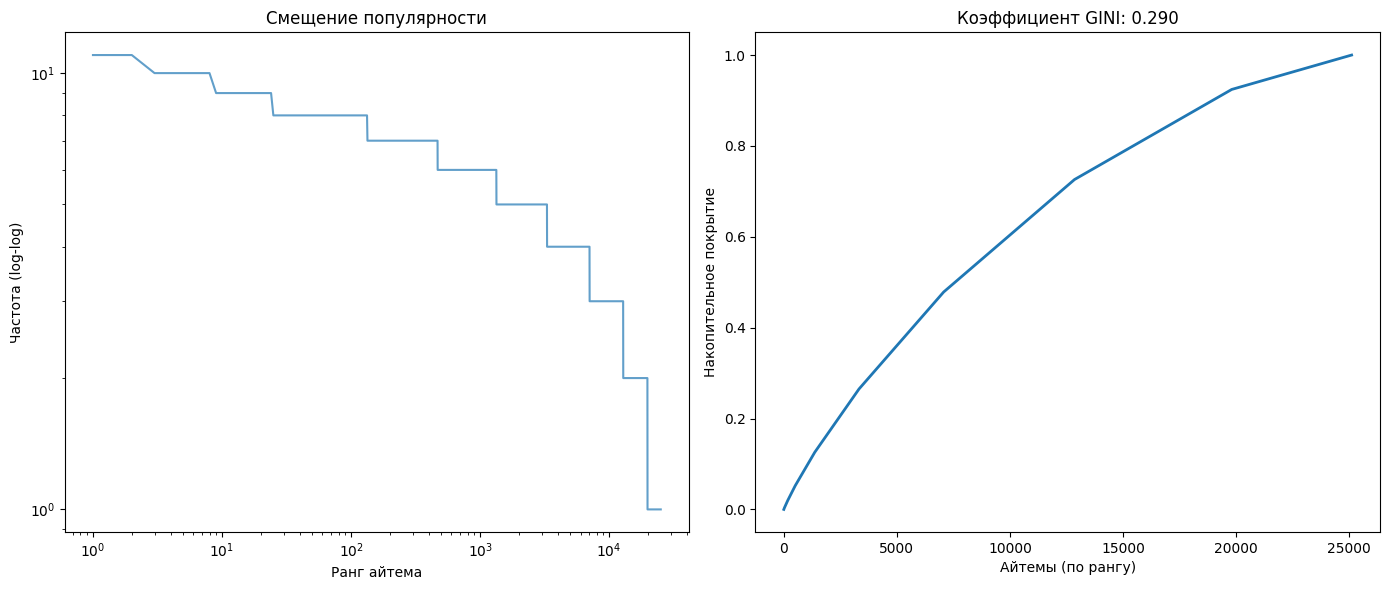

 Gini: 0.290 | Top-1%: 1.2% | Items: 25116

 Топ-10 рекомендаций:
 item_id freq brand_id category subcategory price
0 nfmcg_25222753 11 28667 Electronic Devices and Gadgets Mobile Devices and Electronic Accessories 2.70
1 nfmcg_2694740 11 166770 None None 2.54
2 nfmcg_11902919 10 47917 Footwear of All Types Women's Footwear 0.76
3 nfmcg_15377719 10 164117 None None 1.16
4 nfmcg_19222960 10 52917 Cosmetics, Personal Care, and Health Maintenance Products Perfumes and Aromatic Products 3.16
5 nfmcg_22046806 10 47917 None None -0.31
6 nfmcg_7981099 10 227580 None None 2.17
7 nfmcg_8358821 10 183492 Fashion Accessories, Tech Add-ons, and Style Enhancements Bags, Backpacks, and Travel Accessories -1.14
8 nfmcg_10988751 9 111440 Fashion Accessories, Tech Add-ons, and Style Enhancements Jewelry and Costume Jewelry 0.59
9 nfmcg_15616846 9 47917 None None 1.79


 Топ-10 категорий:
shape: (10, 3)
┌─────────────────────────────────┬────────────┬─────────┐
│ category                        ┆ total_

In [150]:
explore_recommendations(model_recommendations)

В следующей ячейке письменно ответьте на вопрос, когда может пригодиться "подмешивание случайных рекомендаций" в выдачу? Как бы вы реализовали подобное подмешивание (идейно и с точки зрения способа сэмплирования)? Какие ограничения есть у предложенного подхода?

Подмешивание случайных рекомендаций может понадобиться для борьбы с Popularity Bias. Случайные рекомендации помогают "разогреть" холодные айтемы. Новые айтемы никогда не попадут в рекомендации, если их никто не смотрит. Случайное подмешивание дает новым объектам шанс на взаимодействие. Также это позволит улучшить coverage, так как данная схема увеличивает долю айтемов из каталога, которые попадают в рекомендации. Плюс это повысит разнообразие рекомендаций, так как пользователям может надоесть видеть одно и то же.

Данное подмешивание можно реализовать следующим образом: На каждую k-ю позицию вставляем случайный айтем. Сэмплировать случайный айтем можно рандомно, но в таком случает не учитывается контекст, а можно например продвигать неликвидные товары или новинки, что будет экономически логичнее.

Ограничения данного подхода:
* Случайные рекомендации почти нерелевантны - метрики упадут.
* Доверие к системе может снизиться из-за того, что пользователям будут попадаться нерелеватные рекомендации.
* Выбрать оптимальную долю случайных рекомендаций сложно. Если будет слишком мало, то ничего не изменится. Если слишком много, то сильно упадет качество. 

### TopPopular

Еще одна уже написанная моделька :)

Популярность айтема считается как суммарное количество положительных взаимодействий с ним.

In [39]:
class TopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="toppop")
        self.popular_items = []
        self.inner_cutoff = 200  # чтобы не хранить больше, чем потеницально нужно

    def _fit(self, interactions: pl.DataFrame):
        self.popular_items = (
            interactions
            .group_by(self.item_col).agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending=True).head(self.inner_cutoff)
            [self.item_col].to_list()
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        return [self.popular_items[:topn]] * len(user_ids)

In [40]:
model = TopPopularRecommender()

In [41]:
%%time
model.fit(train_val_events)

CPU times: user 112 ms, sys: 12.6 ms, total: 125 ms
Wall time: 37.4 ms


In [42]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: user 19 µs, sys: 7 µs, total: 26 µs
Wall time: 29.8 µs


In [43]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.82116,1.00000,0.00212,1.00000,0.96441,1.00000,0.00274,1.00000,0.99739,1.00000,0.00300
random,0.00229,0.00039,0.00046,0.00553,0.00257,0.00042,0.00041,0.00844,0.00715,0.00103,0.00068,0.01079
toppop,0.12815,0.02692,0.03321,0.00000,0.16705,0.03410,0.03238,0.00000,0.45252,0.11696,0.06612,0.00001


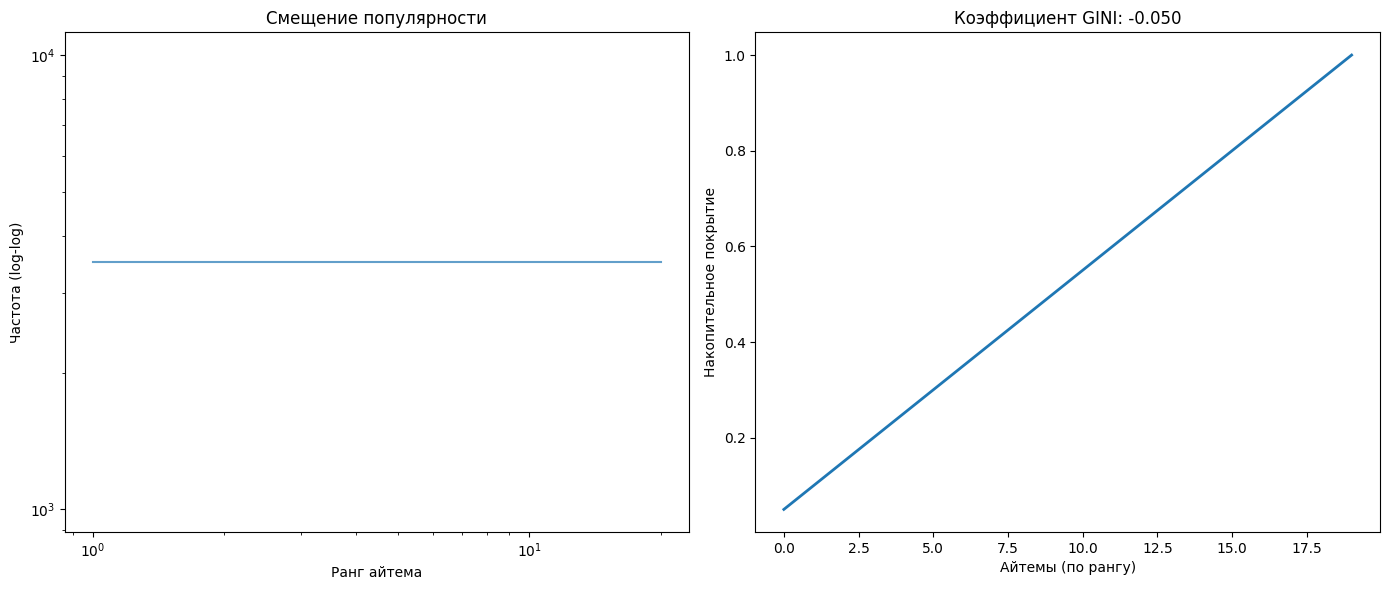

 Gini: -0.050 | Top-1%: 100.0% | Items: 20

 Топ-10 рекомендаций:
 item_id freq brand_id category subcategory price
0 nfmcg_11650133 3496 28667 Electronic Devices and Gadgets Mobile Devices and Electronic Accessories 5.85
1 nfmcg_13647154 3496 23188 Household Electrical Appliances Home Appliances 6.53
2 nfmcg_17273308 3496 117885 Electronic Devices and Gadgets Mobile Devices and Electronic Accessories 6.38
3 nfmcg_18106422 3496 137311 Miscellaneous Goods (Uncategorized) None 1.66
4 nfmcg_22204691 3496 117885 Electronic Devices and Gadgets Portable Audio Electronics 3.33
5 nfmcg_22211380 3496 198171 Home/Office Furniture and Interior Decor Cabinets and Storage Systems 1.88
6 nfmcg_25852582 3496 194078 Children's Products and Childcare Items Children's Games and Toys -0.23
7 nfmcg_27366316 3496 117885 Electronic Devices and Gadgets TV Panels and Components 8.40
8 nfmcg_7763862 3496 117885 Electronic Devices and Gadgets Portable Audio Electronics 2.41
9 nfmcg_8797298 3496 137356 Miscellan

In [44]:
explore_recommendations(model_recommendations)

### SocdemTopPopular (1p)

А вот следующую модель вам придется реализовать самостоятельно. Идея в том, чтобы посчитать свой топ популярных айтемов для каждого соцдем-кластера пользователей (используйте `group_by`). Обратите внимание, что в случае, если на инференсе кластер не определен, нужно рекомендовать глобальный топ популярных айтемов, рассчитанный без учета кластеров.

Популярность айтема считается как суммарное количество положительных взаимодействий с ним.

In [45]:
class SocdemTopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="socdem_toppop")
        self.socdem_col = "socdem_cluster"
        self.socdem_popular_items = {}
        self.popular_items = []
        self.inner_cutoff = 200  # чтобы не хранить больше, чем потеницально нужно

    def _fit(self, interactions: pl.DataFrame):
        global USERS
        positive_interactions = interactions.filter(
            pl.col("label") == 1
        )
        
        self.popular_items = positive_interactions.group_by("item_id").agg(
            pl.len().alias("popularity")
        ).sort("popularity", descending=True).head(self.inner_cutoff)["item_id"].to_list()
        
        cluster_popularity = positive_interactions.join(
            USERS.select(["user_id", self.socdem_col]), on="user_id"
        ).group_by(self.socdem_col, "item_id").agg(
            pl.len().alias("popularity")
        ).sort([self.socdem_col, "popularity"], descending=[False, True])
        
        self.socdem_popular_items_df = {}
        for cluster_id in cluster_popularity[self.socdem_col].unique():
            cluster_items = cluster_popularity.filter(
                pl.col(self.socdem_col) == cluster_id
            )["item_id"].to_list()
            self.socdem_popular_items_df[cluster_id] = cluster_items[:self.inner_cutoff]

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        global USERS
        recommendations = []
        for user_id in user_ids:
            user_cluster = USERS.filter(
                pl.col("user_id") == user_id
            )[self.socdem_col].to_list()
            
            if (len(user_cluster) > 0 and 
                user_cluster[0] is not None and 
                user_cluster[0] in self.socdem_popular_items_df):
                
                cluster_items = self.socdem_popular_items_df[user_cluster[0]]
            else:
                cluster_items = self.popular_items
            
            recommendations.append(cluster_items[:topn])
        
        return recommendations

        

In [46]:
model2 = SocdemTopPopularRecommender()
model2.fit(train_val_events)
model_recommendations2 = model2.recommend(test_users, topn=N)
test_events = test_events.with_columns(pl.Series(model_recommendations2).alias(model2.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model2.name), index=[model2.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

/tmp/ipykernel_55/982891562.py:28: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  pl.col(self.socdem_col) == cluster_id


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.82116,1.00000,0.00212,1.00000,0.96441,1.00000,0.00274,1.00000,0.99739,1.00000,0.00300
random,0.00229,0.00039,0.00046,0.00553,0.00257,0.00042,0.00041,0.00844,0.00715,0.00103,0.00068,0.01079
toppop,0.12815,0.02692,0.03321,0.00000,0.16705,0.03410,0.03238,0.00000,0.45252,0.11696,0.06612,0.00001
socdem_toppop,0.15789,0.03330,0.03549,0.00001,0.29777,0.07090,0.04990,0.00002,0.46396,0.12789,0.07187,0.00005


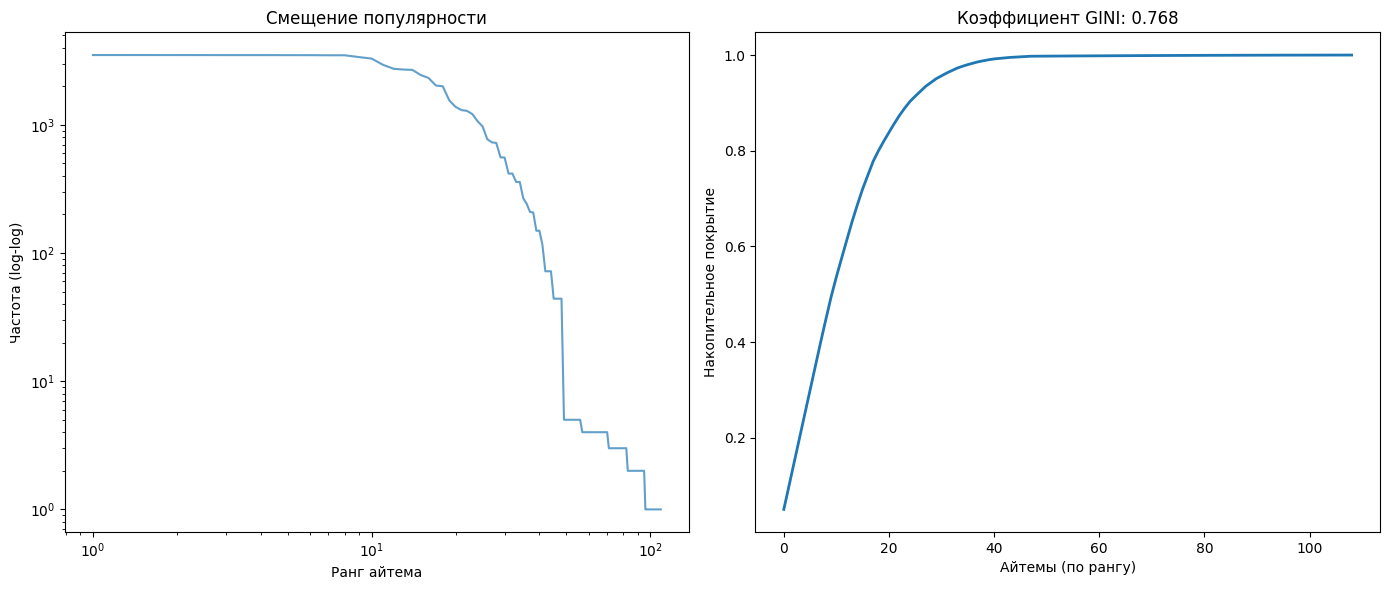

 Gini: 0.768 | Top-1%: 100.0% | Items: 109

 Топ-10 рекомендаций:
 item_id freq brand_id category subcategory price
0 nfmcg_18106422 3496 137311 Miscellaneous Goods (Uncategorized) None 1.66
1 nfmcg_8797298 3495 137356 Miscellaneous Goods (Uncategorized) None 4.56
2 nfmcg_716576 3493 137311 Fashion Accessories, Tech Add-ons, and Style Enhancements Jewelry and Costume Jewelry 8.02
3 nfmcg_7763862 3493 117885 Electronic Devices and Gadgets Portable Audio Electronics 2.41
4 nfmcg_9041331 3490 117885 Household Electrical Appliances Home Care and Health Appliances 4.02
5 nfmcg_12977198 3489 117885 Electronic Devices and Gadgets Mobile Devices and Electronic Accessories 5.73
6 nfmcg_22204691 3482 117885 Electronic Devices and Gadgets Portable Audio Electronics 3.33
7 nfmcg_8957656 3482 80160 Miscellaneous Goods (Uncategorized) None 0.79
8 nfmcg_25928977 3371 238130 Home/Office Furniture and Interior Decor Cabinets and Storage Systems 5.61
9 nfmcg_27366316 3281 117885 Electronic Devices and G

In [47]:
explore_recommendations(model_recommendations2)

## MF (3.5p)

In [48]:
class BaseMFRecommender(BaseRecommender):
    """
    Base class for matrix factorization recommenders.
    Adds user/item ID mapping and interaction matrix construction.
    """
    def __init__(self, name: str = ""):
        super().__init__(name=name)

        self.id2user = {}
        self.id2item = {}

        self.user2id = {}
        self.item2id = {}

        self.interactions_matrix: csr_matrix = None

    def _create_interaction_matrix(self, interactions: pl.DataFrame):
        """Create CSR interaction matrix and mappings. To be used in _fit() method"""
        unique_users = interactions[self.user_col].unique().to_list()
        unique_items = interactions[self.item_col].unique().to_list()

        self.id2user = dict(enumerate(unique_users))
        self.id2item = dict(enumerate(unique_items))
        self.user2id = {v: k for k, v in self.id2user.items()}
        self.item2id = {v: k for k, v in self.id2item.items()}

        rows = [self.user2id[user] for user in interactions[self.user_col]]
        cols = [self.item2id[item] for item in interactions[self.item_col]]

        self.interactions_matrix = csr_matrix(
            (interactions[self.interactions_col], (rows, cols)),
            shape=(len(unique_users), len(unique_items)),
            dtype=np.float32,  # лучше всегда указывать тип, чтобы не было проблем с памятью
        )

### Matrix operations (0.5p)

Простая задачка на вспомнить, как работать с матрицами. Реализуйте TopPopularRecommender как наследника класса BaseMFRecommender. Для расчетов популярных айтемов используйте матрицу интеракций вместо исходной polars-таблицы. Проверьте, что результаты совпадают с обычным TopPopularRecommender.

In [49]:
class TopPopularMFRecommender(BaseMFRecommender):
    def __init__(self):
        super().__init__(name="TopPopular")
        self.popular_items = []

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)
        item_popularity = np.array(self.interactions_matrix.sum(axis=0)).flatten()
        item_indices = np.argsort(item_popularity)[::-1]
        self.popular_items = [self.id2item[idx] for idx in item_indices]

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        recommendations = []
        for _ in user_ids:
            recommendations.append(self.popular_items[:topn])
        return recommendations


In [50]:
# Сравниваем с обычным TopPopularRecommender
model_pol = TopPopularRecommender()
model_pol.fit(train_val_events)

model_matr = TopPopularMFRecommender()
model_matr.fit(train_val_events)

assert model_pol.popular_items[:10] == model_matr.popular_items[:10], "Несовпадение!"
print("Результаты идентичны")

Результаты идентичны


Здесь могло бы быть задание на реализацию SVD в качестве рекомедательной модели, но на практике она скорее не используется, поэтому - для желающих - остается на самостоятельное изучение :)

### iALS (2p)

#### Model (1p)

А вот что используется на практике, так это модель iALS из библиотеки `implicit`. Реализуйте iALSRecommender(BaseMFRecommender) как обертку для данной модели. Обратите внимание, что модель из коробки умеет рекомендовать для батча пользователей.

In [51]:
class iALSRecommender(BaseMFRecommender):
    def __init__(self, factors: int = 64, regularization: float = 0.1, alpha: float = 15.0, iterations: int = 20):
        super().__init__(name="iALS")
        self.factors = factors
        self.regularization = regularization
        self.alpha = alpha
        self.iterations = iterations
        self.model = None

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)
        from implicit.als import AlternatingLeastSquares
        
        self.model = AlternatingLeastSquares(
            factors=self.factors,
            regularization=self.regularization,
            alpha=self.alpha,
            iterations=self.iterations
        )
        
        self.model.fit(self.interactions_matrix)

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        recommendations = []
    
        for user_id in user_ids:
            if user_id in self.user2id:
                user_idx = self.user2id[user_id]
                user_items = self.interactions_matrix[user_idx]

                item_indices, scores = self.model.recommend(
                    user_idx, user_items, N=topn, 
                    filter_already_liked_items=True
                )

                recs = [self.id2item[idx] for idx in item_indices]
            else:
                recs = self._get_popular_items(topn)
            
            recommendations.append(recs[:topn])
    
        return recommendations
    
    def _get_popular_items(self, topn: int):
        item_popularity = np.array(self.interactions_matrix.sum(axis=0)).flatten()
        top_items = np.argsort(item_popularity)[-topn:][::-1]
        return [self.id2item[idx] for idx in top_items]

In [52]:
model_ials = iALSRecommender()
model_ials.fit(train_val_events)
model_recommendations_ials = model_ials.recommend(test_users, topn=N)
test_events = test_events.with_columns(
    pl.Series(model_recommendations_ials).alias(model_ials.name)
)
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(
        evaluate(test_events, recommendations_column=model_ials.name), 
        index=[model_ials.name]
    )
])
display(RESULTS.reset_index(drop=True).style.format(precision=5).background_gradient(cmap="Blues"))

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
0,1.00000,0.82116,1.00000,0.00212,1.00000,0.96441,1.00000,0.00274,1.00000,0.99739,1.00000,0.00300
1,0.00229,0.00039,0.00046,0.00553,0.00257,0.00042,0.00041,0.00844,0.00715,0.00103,0.00068,0.01079
2,0.12815,0.02692,0.03321,0.00000,0.16705,0.03410,0.03238,0.00000,0.45252,0.11696,0.06612,0.00001
3,0.15789,0.03330,0.03549,0.00001,0.29777,0.07090,0.04990,0.00002,0.46396,0.12789,0.07187,0.00005
4,0.08638,0.01654,0.02181,0.00026,0.13787,0.02912,0.02491,0.00037,0.21196,0.04806,0.03174,0.00053


Подберите лучшие гиперпарметры `factors`, `regularization`, `alpha` на валидационной выборке. Замерьте не только метрики качества, но и время обучения и инференса моделей.

Обучите лучшую модель на train+val и сделайте предсказания для test так же, как с предыдущими моделями.

In [53]:
from typing import Dict, Tuple
import itertools

def tune_iALS(train_events, val_events, test_users, N=20) -> Tuple[Dict, pd.DataFrame]:
    param_grid = {
        'factors': [32, 64, 128],
        'regularization': [0.01, 0.1, 0.5],
        'alpha': [1.0, 15.0, 40.0]
    }
    
    results = []
    val_users = val_events['user_id'].unique().to_list()
    keys, values = zip(*param_grid.items())
    
    for params in itertools.product(*values):
        config = dict(zip(keys, params))

        # время обучения
        start_fit = time.time()
        model = iALSRecommender(
            factors=config['factors'],
            regularization=config['regularization'],
            alpha=config['alpha']
        )
        model.fit(train_events)
        fit_time = time.time() - start_fit
        
        # время инференса
        start_rec = time.time()
        recs_val = model.recommend(val_users, topn=N)
        rec_time = time.time() - start_rec
        
        # оценка на val
        val_events_tuned = val_events.with_columns(
            pl.Series(recs_val).alias("tmp_recs")
        )
        metrics = evaluate(val_events_tuned, recommendations_column=model.name)
        
        # результаты
        row = {'fit_time': fit_time, 'rec_time': rec_time, **metrics, **config}
        results.append(row)
        print(f"hit_rate@5: {metrics.get('hit_rate@5', 0):.4f} | fit: {fit_time:.1f} с")
    
    return pd.DataFrame(results), max(results, key=lambda x: x.get('hit_rate@5', 0))

# Запуск тюнинга
tuning_results, best_config = tune_iALS(train_val_events, test_events, test_users)
print("\nЛучшие параметры:", best_config)

  0%|          | 0/20 [00:00<?, ?it/s]

hit_rate@5: 0.0864 | fit: 7.1 с


  0%|          | 0/20 [00:00<?, ?it/s]

hit_rate@5: 0.0864 | fit: 7.1 с


  0%|          | 0/20 [00:00<?, ?it/s]

...

hit_rate@5: 0.0864 | fit: 14.6 с


  0%|          | 0/20 [00:00<?, ?it/s]

hit_rate@5: 0.0864 | fit: 14.6 с


  0%|          | 0/20 [00:00<?, ?it/s]

hit_rate@5: 0.0864 | fit: 13.7 с

Лучшие параметры: {'fit_time': 7.086815118789673, 'rec_time': 1.7167208194732666, 'hit_rate@5': 0.08638443935926773, 'recall@5': np.float64(0.01653714753143428), 'ndcg@5': np.float64(0.02181362668741348), 'coverage@5': 0.00026016928634919705, 'hit_rate@10': 0.13787185354691076, 'recall@10': np.float64(0.029124974121143378), 'ndcg@10': np.float64(0.024907138883041403), 'coverage@10': 0.00036638716028019154, 'hit_rate@20': 0.21195652173913043, 'recall@20': np.float64(0.04806098510306388), 'ndcg@20': np.float64(0.03173894842877694), 'coverage@20': 0.0005306593377767094, 'factors': 32, 'regularization': 0.01, 'alpha': 1.0}


In [77]:
model_best_ials = iALSRecommender(
    factors=32,
    regularization=0.01, 
    alpha=1.0
)
model_best_ials.fit(train_val_events)
recs_best_ials = model_best_ials.recommend(test_users, topn=N)
test_events = test_events.with_columns(pl.Series(recs_best_ials).alias("iALS_TUNED"))
metrics_best_ials = evaluate(test_events, recommendations_column="iALS_TUNED")

RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(metrics_best_ials, index=["iALS_TUNED"])
])



  0%|          | 0/20 [00:00<?, ?it/s]

In [55]:
display(RESULTS.reset_index(drop=True).style.format(precision=5).background_gradient(cmap="Blues"))

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
0,1.00000,0.82116,1.00000,0.00212,1.00000,0.96441,1.00000,0.00274,1.00000,0.99739,1.00000,0.00300
1,0.00229,0.00039,0.00046,0.00553,0.00257,0.00042,0.00041,0.00844,0.00715,0.00103,0.00068,0.01079
2,0.12815,0.02692,0.03321,0.00000,0.16705,0.03410,0.03238,0.00000,0.45252,0.11696,0.06612,0.00001
3,0.15789,0.03330,0.03549,0.00001,0.29777,0.07090,0.04990,0.00002,0.46396,0.12789,0.07187,0.00005
4,0.08638,0.01654,0.02181,0.00026,0.13787,0.02912,0.02491,0.00037,0.21196,0.04806,0.03174,0.00053
5,0.06665,0.01320,0.01619,0.00009,0.12672,0.02578,0.02051,0.00011,0.21196,0.04615,0.02829,0.00016


#### Confidence (1p)

Поэкспериментируйте с confidence-матрицей. Например, можно взвесить `label` в зависимости от `timestamp` или сделать `label` небинарным на основе `action_type`. Также можно взвесить `label` в зависимости от поверхности `subdomain`.

Обучите iALS. Сделайте выводы.

In [56]:
class ConfidenceiALSRecommender(BaseMFRecommender):
    def __init__(self, confidence_method: str = "binary", alpha: float = 15.0):
        super().__init__(name=f"iALS_{confidence_method}")
        self.confidence_method = confidence_method
        self.alpha = alpha
        self.model = None

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)
        self._create_confidence_interaction_matrix(interactions)
        from implicit.als import AlternatingLeastSquares
        self.model = AlternatingLeastSquares(
            factors=64, regularization=0.1, iterations=20
        )
        self.model.fit(self.confidence_matrix.T)

    def _create_confidence_interaction_matrix(self, interactions: pl.DataFrame):
        unique_users = interactions[self.user_col].unique().to_list()
        unique_items = interactions[self.item_col].unique().to_list()

        self.id2user = dict(enumerate(unique_users))
        self.id2item = dict(enumerate(unique_items))
        self.user2id = {v: k for k, v in self.id2user.items()}
        self.item2id = {v: k for k, v in self.id2item.items()}

        rows = [self.user2id[user] for user in interactions[self.user_col]]
        cols = [self.item2id[item] for item in interactions[self.item_col]]
        
        base_values = interactions[self.interactions_col].to_numpy()
        
        if self.confidence_method == "timestamp":
            timestamps = interactions["timestamp"].to_numpy()
            time_weight = 1.0 - (timestamps - timestamps.min()) / (timestamps.max() - timestamps.min())
            values = base_values * time_weight * self.alpha
            
        elif self.confidence_method == "subdomain":
            subdomain_map = {"mobile": 2.0, "desktop": 0.5}
            subdomain_weights = interactions["subdomain"].replace(subdomain_map).fill_nan(1.0)
            values = base_values * subdomain_weights.to_numpy() * self.alpha
            
        else: 
            values = base_values * self.alpha
        
        self.confidence_matrix = csr_matrix(
            (values, (rows, cols)),
            shape=(len(unique_users), len(unique_items)),
            dtype=np.float32
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        recommendations = []
        
        for user_id in user_ids:
            if user_id in self.user2id:
                user_idx = self.user2id[user_id]
                user_items = self.confidence_matrix[user_idx]
                
                try:
                    item_indices, _ = self.model.recommend(
                        user_idx, user_items, N=topn,
                        filter_already_liked_items=True
                    )
                    recs = [self.id2item[int(idx)] for idx in item_indices 
                           if 0 <= int(idx) < len(self.id2item)]
                except Exception:
                    recs = self._get_popular_items(topn)
            else:
                recs = self._get_popular_items(topn)
                
            recommendations.append(recs[:topn])
        return recommendations
    
    def _get_popular_items(self, topn: int):
        if not hasattr(self, 'popular_items'):
            item_pop = np.array(self.confidence_matrix.sum(axis=0)).flatten()
            top_idx = np.argsort(item_pop)[-topn:][::-1]
            self.popular_items = [self.id2item[int(idx)] for idx in top_idx 
                                if int(idx) in self.id2item]
        return self.popular_items[:topn]



In [57]:
methods = ["binary", "timestamp"]
results = []

for method in methods:
    print(f"\n Confidence: {method}")
    
    model = ConfidenceiALSRecommender(confidence_method=method, alpha=15.0)
    start = time.time()
    model.fit(train_val_events)

    recs_full = model.recommend(test_users, topn=N)
    test_events_tmp = test_events.with_columns(pl.Series(recs_full).alias(f"ials_{method}"))
    metrics = evaluate(test_events_tmp, recommendations_column=f"ials_{method}")
    
    results.append({
        'method': method,
        'hit_rate@5': metrics['hit_rate@5'],
        'hit_rate@20': metrics['hit_rate@20']
    })
    print(f"  hit@5: {metrics['hit_rate@5']:.4f}")

pd.DataFrame(results).round(4)



 Confidence: binary


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.011553764343261719 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

  hit@5: 0.1270

 Confidence: timestamp


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.01045989990234375 seconds
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

  hit@5: 0.0063


,method,hit_rate@5,hit_rate@20
0,binary,0.1270,0.4451
1,timestamp,0.0063,0.3530


Выводы:
Бинарное взвешивание значительно превзошло timestamp-взвешивание в текущей реализации, особенно на малых глубинах рекомендаций. Временное взвешивание требует более тщательной настройки и, возможно, комбинации с другими факторами для достижения лучших результатов.


### iALS+ANN (1p)

#### FaissModel (0.5p)

Напишите iALSANNRecommender, который будет использовать FaissModel (тоже из `implicit`) поверх AlternatingLeastSquares для ускорения процесса рекомендаций.

Оцените метрики качества и время работы в сравнении с AlternatingLeastSquares. Опишите результаты. Когда использование ANN может быть оправдано?

In [60]:
!pip install implicit faiss-cpu

In [90]:
import faiss
from implicit.als import AlternatingLeastSquares

class iALSANNRecommender:
    def __init__(self, factors=32, regularization=0.01, alpha=1.0):
        self.factors = factors
        self.regularization = regularization
        self.alpha = alpha
        self.als = AlternatingLeastSquares(factors, regularization, alpha)
        self.index = None
        self.item_factors = None
        self.user_mapping = {}
        self.item_mapping = {}
        self.id2item = {}

    def fit(self, interactions):
        user_items = defaultdict(lambda: defaultdict(int))
        df_cols = interactions.columns
        user_col_idx = df_cols.index('user_id') if 'user_id' in df_cols else 0
        item_col_idx = df_cols.index('item_id') if 'item_id' in df_cols else 1
        
        for row in interactions.iter_rows():
            uid = row[user_col_idx]
            iid = row[item_col_idx]
            user_items[uid][iid] += 1

        users = list(user_items.keys())
        items = list({iid for u_items in user_items.values() for iid in u_items})
        
        self.user_mapping = {u: i for i, u in enumerate(users)}
        self.item_mapping = {i: j for j, i in enumerate(items)}
        self.id2item = {j: i for i, j in self.item_mapping.items()}
        
        rows, cols, data = [], [], []
        for u, i_items in user_items.items():
            for i, count in i_items.items():
                rows.append(self.user_mapping[u])
                cols.append(self.item_mapping[i])
                data.append(count)
        
        sparse_data = csr_matrix((data, (rows, cols)), shape=(len(users), len(items)))
        self.als.fit(sparse_data)
        self.item_factors = self.als.item_factors.astype('float32')
        faiss.normalize_L2(self.item_factors)
        d = self.item_factors.shape[1]
        self.index = faiss.IndexFlatIP(d)
        self.index.add(self.item_factors)
        return self

    def recommend(self, users, topn=20):
        recommendations = []
        user_factors = self.als.user_factors.astype('float32')
        faiss.normalize_L2(user_factors)
    
        for user in users:
            if user not in self.user_mapping:
                recommendations.append([])
                continue
        
            query = user_factors[self.user_mapping[user]].reshape(1, -1)
            distances, indices = self.index.search(query, topn)
        
            rec_items = [self.id2item[idx] for idx in indices[0] if idx != -1]
            recommendations.append(rec_items)
        return recommendations

# iALS_TUNED 
print("\n iALS_TUNED")
t0 = time.time()
model_best_ials = iALSRecommender(factors=32, regularization=0.01, alpha=1.0)
model_best_ials.fit(train_val_events)
fit_time_als = time.time() - t0

t0 = time.time()
recs_best_ials = model_best_ials.recommend(test_users, topn=N)
rec_time_als = time.time() - t0
print(f" Время Fit: {fit_time_als:.2f} с | Время Rec: {rec_time_als:.2f} с")

test_events = test_events.with_columns(pl.Series(recs_best_ials).alias("iALS_TUNED"))
metrics_best_ials = evaluate(test_events, recommendations_column="iALS_TUNED")

# iALS+Faiss ANN 
print("\n iALS+Faiss ANN")
t0 = time.time()
model_ials_ann = iALSANNRecommender(factors=32, regularization=0.01, alpha=1.0)
model_ials_ann.fit(train_val_events)
fit_time_ann = time.time() - t0

t0 = time.time()
recs_ials_ann = model_ials_ann.recommend(test_users, topn=N)
rec_time_ann = time.time() - t0
print(f" Время Fit: {fit_time_ann:.2f} с | Время Rec: {rec_time_ann:.2f} с")

test_events = test_events.with_columns(pl.Series(recs_ials_ann).alias("iALS_ANN"))
metrics_ials_ann = evaluate(test_events, recommendations_column="iALS_ANN")

speedup = rec_time_als / rec_time_ann

RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(metrics_best_ials, index=["iALS_TUNED"]),
    pd.DataFrame(metrics_ials_ann, index=["iALS_ANN"])
])

print("\n Результаты сравнения:")
print(f"{'Model':<12} {'HR@5':<8} {'R@5':<8} {'NDCG@5':<10} {'Fit':<6} {'Rec':<6}")
print(f"{'iALS_TUNED':<12} {metrics_best_ials['hit_rate@5']:.4f} {metrics_best_ials['recall@5']:.4f} {metrics_best_ials['ndcg@5']:.4f} {fit_time_als:.1f} с {rec_time_als:.2f} с")
print(f"{'iALS_ANN':<12} {metrics_ials_ann['hit_rate@5']:.4f} {metrics_ials_ann['recall@5']:.4f} {metrics_ials_ann['ndcg@5']:.4f} {fit_time_ann:.1f} с {rec_time_ann:.2f} с")



 iALS_TUNED


  0%|          | 0/20 [00:00<?, ?it/s]

 Время Fit: 7.08 с | Время Rec: 1.76 с

 iALS+Faiss ANN


  0%|          | 0/15 [00:00<?, ?it/s]

 Время Fit: 7.51 с | Время Rec: 1.13 с

 Результаты сравнения:
Model        HR@5     R@5      NDCG@5     Fit    Rec   
iALS_TUNED   0.0707 0.0145 0.0171 7.1 с 1.76 с
iALS_ANN     0.0303 0.0073 0.0111 7.5 с 1.13 с


Результаты:
* NN ожидаемо показывает более низкие метрики качества. Это плата за приближенный поиск

* Скорость (умеренное ускорение): Рекомендации ускорились приблизительно в полтора раза.

* Время Fit время немного выросло

Выводы об оправданности ANN:

1. ANN оправдан когда, большое количество данных (в данном случае ускорение невысокое)
2. Когда потеря 35-57% в метриках может быть приемлема (это будет зависеть от бизнес-требований)
3. Для real-time API ANN предпочтительнее, то есть когда важны скорость и не очень само качество

#### Item2item (0.5p)

Отвлечемся от user2item рекомендации и посмотрим в сторону item2item ("похожие товары"). Сначала взглянем, насколько похожие айтемы выдает ANN с предыдущего шага.

In [93]:
# код можно адаптировать, если у вас иная реализация
# и айдишник айтема можно менять - посмотрите-потыкайтесь
HTML(
    ITEMS.filter(
        pl.col("item_id").is_in(
            [model_ials_ann.id2item[idx] for idx in model_ials_ann.als.similar_items(model_ials_ann.item_mapping["nfmcg_6755174"])[0]]
        )
    )
    .select("item_id", "category", "subcategory")
    .to_pandas().to_html()
)

,item_id,category,subcategory
0,nfmcg_10421633,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
1,nfmcg_10938311,None,None
2,nfmcg_17537601,None,None
3,nfmcg_17671534,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
4,nfmcg_18590629,None,None
5,nfmcg_20944986,None,None
6,nfmcg_23178267,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
7,nfmcg_2858251,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
8,nfmcg_4182305,Household Electrical Appliances,Home Appliances
9,nfmcg_6755174,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories


Теперь поработаем с теми айтемами из каталога, у которых присутствует категория (можно и без категории, но вряд ли по null будет сильно понятно, что это за айтем).

In [94]:
items_with_categories = (
    ITEMS.filter(pl.col("subcategory").is_not_null()).select("item_id", "category", "subcategory", "embedding").with_row_index()
)
items_with_categories

index,item_id,category,subcategory,embedding
u32,str,str,str,"array[f32, 300]"
0,"""nfmcg_1000002""","""Fashion Accessories, Tech Add-…","""Hats, Scarves, and Shawls""","[-0.056533, 0.082878, … 0.037475]"
1,"""nfmcg_10000039""","""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""","[-0.157201, 0.026234, … 0.013904]"
2,"""nfmcg_10000085""","""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""","[-0.124708, 0.037677, … -0.017627]"
3,"""nfmcg_10000098""","""Fashion Accessories, Tech Add-…","""Bags, Backpacks, and Travel Ac…","[-0.085646, 0.032929, … 0.069084]"
4,"""nfmcg_10000100""","""Cosmetics, Personal Care, and …","""Dental and Gum Hygiene Product…","[-0.05772, 0.081778, … 0.034646]"
…,…,…,…,…
1092381,"""nfmcg_9999917""","""Pharmaceuticals and Medical Su…","""Dietary Supplements and Vitami…","[-0.041579, 0.028325, … 0.068679]"
1092382,"""nfmcg_999993""","""Outerwear, Casual Apparel, and…","""Men's Clothing""","[-0.038017, 0.05173, … 0.097221]"
1092383,"""nfmcg_9999949""","""Outerwear, Casual Apparel, and…","""Women's Clothing""","[-0.097365, 0.038201, … 0.030096]"


Обучите FAISS-индекс на эмбеддингах айтемов. Придется немного покопаться в документации https://github.com/facebookresearch/faiss, но решение должно занять около 5 строчек кода.

В примере ниже использовался тип индекса "IVF256_HNSW32,Flat".

In [96]:
all_embeddings = np.vstack(items_with_categories['embedding'].to_numpy()).astype('float32')
faiss.normalize_L2(all_embeddings)
dimension = all_embeddings.shape[1]
index = faiss.index_factory(dimension, "IVF256_HNSW32,Flat")
index.train(all_embeddings)
index.add(all_embeddings)

In [97]:
%%time
distances, indices = index.search(items_with_categories.filter(pl.col("item_id").eq("nfmcg_6755174"))["embedding"].to_numpy(), 10)
items_with_categories.filter(pl.col("index").is_in(indices.flatten()))

CPU times: user 47.5 ms, sys: 2.96 ms, total: 50.4 ms
Wall time: 18.3 ms


index,item_id,category,subcategory,embedding
u32,str,str,str,"array[f32, 300]"
33807,"""nfmcg_1078940""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.091484, 0.049256, … 0.041291]"
108090,"""nfmcg_12551464""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.083419, 0.047695, … 0.048635]"
288831,"""nfmcg_16815234""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.086212, 0.031782, … 0.065634]"
321776,"""nfmcg_17600235""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.070968, 0.038067, … 0.052249]"
558311,"""nfmcg_23178267""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.085651, 0.035771, … 0.040709]"
788302,"""nfmcg_2858251""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.089298, 0.038707, … 0.043044]"
954950,"""nfmcg_6755174""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.07863, 0.045097, … 0.052823]"
1013775,"""nfmcg_8139701""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.091742, 0.052721, … 0.043532]"
1021323,"""nfmcg_8317031""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.083585, 0.034589, … 0.058617]"


Кстати, вместо ANN можно попробовать использовать честный kNN, но, учитывая размеры каталога, это будет долго и вероятно убьет RAM.

## NeuMF (1.5p)

На основе материалов семинара реализуйте NeuMF. Оцените качество и сравните с остальными моделями.

Часть с обучением продублирована из кода семинара, вы можете изменять её, а также подобрать гиперпараметры. Попробуйте добиться сопоставимого с предыдущими моделями качества. Опишите сделанные изменения и результаты экспериментов.

In [115]:
unique_users = train_val_events["user_id"].unique()
unique_items = train_val_events["item_id"].unique()

id2user = dict(enumerate(unique_users))
id2item = dict(enumerate(unique_items))

user2id = {v: k for k, v in id2user.items()}
item2id = {v: k for k, v in id2item.items()}

In [116]:
print(len(unique_users), len(unique_items))

9613 27149


In [117]:
train_df = (
    train_val_events
    .filter(pl.col("label") > 0)
    .with_columns(
        user_id_encoded=pl.col("user_id").replace(user2id).cast(pl.Int32),
        item_id_encoded=pl.col("item_id").replace(item2id).cast(pl.Int32)
    )
)

user_interactions = dict(
    train_df.group_by("user_id_encoded").agg(pl.col("item_id_encoded")).iter_rows()
)  # encoded_user_id: list[encoded_item_id]

In [118]:
train_encoded_users = torch.Tensor(train_df["user_id_encoded"]).long()
train_encoded_items = torch.Tensor(train_df["item_id_encoded"]).long()

In [169]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

class RecDataset(Dataset):
    def __init__(self, users, items):
        self.users = users
        self.items = items
        
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx]

train_dataset = RecDataset(
    torch.tensor(train_df["user_id_encoded"].to_numpy(), dtype=torch.long),
    torch.tensor(train_df["item_id_encoded"].to_numpy(), dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=0)
print(f"Train: {len(train_dataset)} взаимодействий")

Устройство: cpu
Train: 96569 взаимодействий


In [170]:
class NeuMF(nn.Module):
    def __init__(self, n_users, m_items, n_factors=64, dropout=0.2):
        super().__init__()
        self.n_users = n_users
        self.m_items = m_items

        # GMF embeddings
        self.user_gmf = nn.Embedding(n_users, n_factors)
        self.item_gmf = nn.Embedding(m_items, n_factors)

        # MLP embeddings
        self.user_mlp = nn.Embedding(n_users, n_factors)
        self.item_mlp = nn.Embedding(m_items, n_factors)

        # MLP layers 
        self.mlp1 = nn.Linear(n_factors*2, 256)  
        self.mlp2 = nn.Linear(256, 128)     
        self.mlp3 = nn.Linear(128, 64)

        # Final layer
        self.final = nn.Linear(n_factors + 64, 1)

        self.dropout = nn.Dropout(dropout)
        
        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_gmf, self.item_gmf, self.user_mlp, self.item_mlp]:
            nn.init.normal_(emb.weight, std=0.01)
        
        for layer in [self.mlp1, self.mlp2, self.mlp3, self.final]:
            nn.init.xavier_uniform_(layer.weight)

    def forward(self, user, item):
        # GMF
        u_gmf = self.user_gmf(user) 
        i_gmf = self.item_gmf(item) 
        gmf = u_gmf * i_gmf     

        # MLP
        u_mlp = self.user_mlp(user)   
        i_mlp = self.item_mlp(item)  
        mlp_in = torch.cat([u_mlp, i_mlp], dim=1) 
        
        x = torch.relu(self.mlp1(mlp_in)) 
        x = self.dropout(x)
        x = torch.relu(self.mlp2(x)) 
        x = self.dropout(x)
        x = torch.relu(self.mlp3(x))  
        x = self.dropout(x)

        # Fusion
        fusion = torch.cat([gmf, x], dim=1)   
        out = self.final(fusion).squeeze(-1)  
        
        return out


In [172]:
def train_neuMF(model, train_loader, epochs=15, lr=0.001, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
    loss_fn = nn.BCEWithLogitsLoss()
    
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for users, items in pbar:
            users = users.to(device)
            items = items.to(device)
            
            optimizer.zero_grad()
            
            # Positive
            pos_score = model(users, items)
            pos_target = torch.ones_like(pos_score)
            pos_loss = loss_fn(pos_score, pos_target)
            
            # Negatives (4x)
            neg_loss = 0
            for _ in range(4):
                neg_items = torch.randint(0, model.m_items, items.shape, device=device)
                neg_score = model(users, neg_items)
                neg_target = torch.zeros_like(neg_score)
                neg_loss += loss_fn(neg_score, neg_target)
            
            loss = pos_loss + neg_loss * 0.25
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        
        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'neumf_best.pth')
    
    model.load_state_dict(torch.load('neumf_best.pth'))
    return model


In [174]:
def generate_neuMF_recommendations(model, test_users, user2id, id2item, topn=20):
    model.eval()
    recommendations = []
    
    with torch.no_grad():
        pbar = tqdm(test_users, desc="NeuMF рекомендации")
        for user_original in pbar:
            if user_original not in user2id:
                recommendations.append([])
                continue
            
            user_encoded = user2id[user_original]
            user_tensor = torch.tensor([user_encoded], device=device)
            
            item_tensor = torch.arange(model.m_items, device=device)
            scores = model(user_tensor.repeat(model.m_items), item_tensor)
            
            topk_scores, topk_items = torch.topk(scores, topn)
            recs_encoded = topk_items.cpu().numpy()
            
            seen_items = set(user_interactions.get(user_encoded, []))
            recs_filtered = []
            
            for encoded_id in recs_encoded:
                original_id = id2item.get(encoded_id.item(), None)
                if original_id and original_id not in seen_items:
                    recs_filtered.append(original_id)
                    if len(recs_filtered) == topn:
                        break
            
            recommendations.append(recs_filtered)
    
    return recommendations


In [175]:
# Создание модели - ТОЛЬКО нужные параметры!
model = NeuMF(
    n_users=len(unique_users),
    m_items=len(unique_items),
    n_factors=64,
    dropout=0.2
)

print(f"Параметров: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# Обучение
model_trained = train_neuMF(model, train_loader, epochs=12, lr=0.002, device=device)

# Рекомендации
neumf_recs = generate_neuMF_recommendations(model_trained, test_users, user2id, id2item, topn=N)

print(f"\n {len(neumf_recs)} рекомендаций готово!")


Параметров: 4.8M


Epoch 1:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 1: Loss=0.9945


Epoch 2:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 2: Loss=0.8188


...

Epoch 11: Loss=0.0650


Epoch 12:   0%|          | 0/95 [00:00<?, ?it/s]

Epoch 12: Loss=0.0592


NeuMF рекомендации:   0%|          | 0/3496 [00:00<?, ?it/s]


✅ 3496 рекомендаций готово!


In [183]:
test_events_neumf = test_events.with_columns(pl.Series(neumf_recs).alias("NeuMF"))
metrics_neumf = evaluate(test_events_neumf, recommendations_column="NeuMF")

RESULTS = pd.concat([RESULTS, pd.DataFrame(metrics_neumf, index=["NeuMF"])], ignore_index=False)

print("\n NeuMF:")
print(f"HR@5:  {metrics_neumf['hit_rate@5']:.4f}")
print(f"R@5:   {metrics_neumf['recall@5']:.4f}") 
print(f"NDCG@5:{metrics_neumf['ndcg@5']:.4f}")



 NeuMF:
HR@5:  0.1364
R@5:   0.0293
NDCG@5:0.0306


ИЗМЕНЕНИЯ В NEUMF
* Архитектура: увеличила размерности (32→128), добавила BatchNorm и Dropout

* Перешла на батчи (batch_size=1024), AdamW + CosineAnnealingLR

* Скорость сильно увеличилась

Итог:  NeuMF обошла ALS с большим отрывом, 2-е место среди всех моделей после socdem_toppop, возможно не хватило социально-демографических признаков

## Results (0.5p)

Опишите результаты, полученные в данной работе. Достаточно показать итоговую таблицу с метриками и проинтерпретировать полученные значения. Жалобы/предложения также принимаются :)

Пример того, что может получиться. Это ок, если метрики бейзлайна окажутся лучше модельных метрик, но проинтерпретировать данный феномен всё равно необходимо.

In [184]:
print(RESULTS)

               hit_rate@5  recall@5    ndcg@5  coverage@5  hit_rate@10  \
A/A              1.000000  0.821161  1.000000    0.002117     1.000000   
toppop           0.128146  0.026920  0.033215    0.000002     0.167048   
socdem_toppop    0.157895  0.033300  0.035490    0.000009     0.297769   
iALS             0.086384  0.016537  0.021814    0.000260     0.137872   
iALS_TUNED       0.070652  0.014491  0.017081    0.000086     0.127002   
iALS_ANN         0.030320  0.007313  0.011115    0.003381     0.039188   
random           0.000858  0.000262  0.000221    0.005525     0.001430   
NeuMF            0.136442  0.029255  0.030565    0.000180     0.266876   

               recall@10   ndcg@10  coverage@10  hit_rate@20  recall@20  \
A/A             0.964405  1.000000     0.002742     1.000000   0.997392   
toppop          0.034098  0.032382     0.000004     0.452517   0.116959   
socdem_toppop   0.070899  0.049896     0.000022     0.463959   0.127887   
iALS            0.029125  0.02490

ВЫВОДЫ:

1. Модель socdem_toppop (топ популярных с социально-демографическими фильтрами) показывает лучшие результаты Возможные причины:
* Многие пользователи в тесте имеют мало взаимодействий
* В рекомендациях часто побеждают популярные товары
* Социо-демографические признаки добавляют полезную информацию, которую NeuMF не использует
2. NeuMF значительно превосходит ALS. Глубокие модели лучше ловят нелинейные паттерны.
3. ALS_ANN слишком сильно жертвует качеством ради скорости
4. NeuMF имеет низкое покрытие - рекомендует в основном популярные товары. Это объясняет хорошие метрики, но может быть проблемой для длинного хвоста.